# ARP (adiabatic rapid passage) physics, broken down piece by piece

This notebook walks through **every** physics ingredient behind the staircase
ARP composer in `lmt_sim/arp.py` and behind each assertion in
`tests/test_arp.py`, in the smallest verifiable steps I could manage. The goal
is that you can check the physics line by line: each section states the
governing equation, computes the quantity from the library code, and (where a
closed form or an independent integration exists) checks the two against each
other.

The single most important physics claim — the one the whole
`docs/arp_frame_change_finding.md` saga is about — is in **Section 5**: an ARP
chirp modelled as a staircase of fixed-detuning sub-pulses is just the **product
of the per-block propagators, with no inter-block "frame change"**. We validate
that product three independent ways (continuous-sweep ODE, Landau–Zener,
adiabatic inversion) and against the full row-based composer.

## Map of the notebook

1. Constants and the physical setup (Sr-87 clock transition).
2. The single-arm closed two-level system: why a 2×2 suffices.
3. The Bordé pulse Hamiltonian and its propagator (Eqs. 7, 12, 13).
4. Resonance: why `detuning = 0` is *not* resonant; the recoil-shifted centre.
5. The staircase, and why composing it needs **no** frame change.
6. Validation 1 — the textbook continuous-sweep ARP ODE.
7. Validation 2 — the Landau–Zener diabatic tail.
8. Validation 3 — adiabatic inversion on a robust plateau.
9. Validation 4 — symmetry about resonance.
10. The imprinted phase and `ref_detuning_hz` (integral of laser phase).
11. Equivalence to the full row-based composer.
12. Bloch-sphere picture: the state following the dressed eigenstate.

In [1]:
import sys

sys.path.insert(0, "..")

import numpy as np
from scipy import constants
from scipy.integrate import solve_ivp
from scipy.linalg import expm
import matplotlib.pyplot as plt

from lmt_sim import arp
from lmt_sim import lmt_simulation as sim
from lmt_sim.lmt_simulation import (
    AtomState,
    K_WAVEVECTOR,
    MASS_ATOM,
    RABI_FREQ,
    RECOIL_FREQUENCY_HZ,
    T_PI,
    TRANSITION_WAVELENGTH,
)
from lmt_sim.lmt_sequence import Pulse, run_pulse_sequence_in_borde_representation

np.set_printoptions(precision=6, suppress=False, linewidth=100)

## 1. Constants and the physical setup

We are on the Sr-87 ${}^1S_0 \to {}^3P_0$ clock transition at
$\lambda = 698\,\mathrm{nm}$. Two derived scales control everything below:

* the **single-photon recoil velocity** $v_\mathrm{rec} = \hbar k / M$ — the
  velocity kick one absorbed photon gives the atom;
* the **recoil frequency** $\delta_\mathrm{rec} = \hbar k^2 / 2M$ (the kinetic
  energy of that kick, as a frequency). In Hz this is
  `RECOIL_FREQUENCY_HZ`.

The library expresses **all** frequencies in Hz (not angular), and uses the
"$\pi$-not-$2\pi$" convention: the Bordé coupling is
$\omega_{ab} = \pi\,\Omega_\mathrm{Hz}$ (the factor of $2\pi$ from
$\omega = 2\pi f$ has combined with the $\tfrac12$ in $H/\hbar$). Keep that
factor of $\pi$ in mind — it reappears everywhere.

In [2]:
v_recoil = constants.hbar * K_WAVEVECTOR / MASS_ATOM
delta_rec_angular = constants.hbar * K_WAVEVECTOR**2 / (2 * MASS_ATOM)

print(f"wavelength               lambda = {TRANSITION_WAVELENGTH * 1e9:.3f} nm")
print(f"wavevector               k      = {K_WAVEVECTOR:.6e} rad/m")
print(f"atom mass                M      = {MASS_ATOM:.6e} kg")
print(f"recoil velocity          v_rec  = {v_recoil * 1e3:.6f} mm/s")
print(f"recoil freq (angular)    d_rec  = {delta_rec_angular:.6e} rad/s")
print(f"recoil freq (Hz)         d_rec  = {RECOIL_FREQUENCY_HZ:.6f} Hz")
print()
print(
    f"check: hbar k^2/2M /(2pi) = {delta_rec_angular / (2 * np.pi):.6f} Hz"
    f"  == RECOIL_FREQUENCY_HZ ({RECOIL_FREQUENCY_HZ:.6f})"
)
print()
print(f"default pi-pulse Rabi     Omega  = {RABI_FREQ:.3f} Hz")
print(f"default pi-pulse time     T_pi   = {T_PI * 1e6:.3f} us  (= 1/(2 Omega))")

wavelength               lambda = 698.000 nm
wavevector               k      = 9.001698e+06 rad/m
atom mass                M      = 1.444669e-25 kg
recoil velocity          v_rec  = 6.571012 mm/s
recoil freq (angular)    d_rec  = 2.957513e+04 rad/s
recoil freq (Hz)         d_rec  = 4707.028608 Hz

check: hbar k^2/2M /(2pi) = 4707.028608 Hz  == RECOIL_FREQUENCY_HZ (4707.028608)

default pi-pulse Rabi     Omega  = 11111.111 Hz
default pi-pulse time     T_pi   = 45.000 us  (= 1/(2 Omega))


## 2. The single-arm closed two-level system

A laser pulse on one arm (one $k$-direction, `k_sign = +1` here) couples
$|g, m\rangle \leftrightarrow |e, m+1\rangle$: absorbing a $+k$ photon adds one
unit of recoil momentum *and* flips the internal state. For a single arm those
two states form a **closed** two-level system — nothing else is reached — so the
full ensemble bookkeeping of `lmt_simulation` (which doubles the number of rows
at every pulse) is, for one arm, pure redundancy. `lmt_sim.arp` exploits this:
it propagates a single **2×2** matrix.

State-vector order throughout `lmt_sim.arp` and
`lmt_simulation._single_pulse_propagator_2x2` is `[c_excited, c_ground]`.
We will always start in the ground state, i.e. the vector `[0, 1]`.

In [3]:
psi_ground = np.array([0.0, 1.0], dtype=complex)  # [c_excited, c_ground]
print("initial state [c_excited, c_ground] =", psi_ground)

initial state [c_excited, c_ground] = [0.+0.j 1.+0.j]


## 3. The Bordé pulse Hamiltonian and its propagator

In the rotating frame of one arm, Bordé (Phys. Rev. A **30**, 1836, Eqs. 7–8)
gives the 2×2 Hamiltonian for a fixed pulse, in the library's exact sign
convention (state order `[excited, ground]`), as

$$ H/\hbar \;=\; -\tfrac12\,\Omega_3\,\sigma_z
   \;-\; \omega_{ab}\big(\cos\phi\,\sigma_x + \sin\phi\,\sigma_y\big)
   \;=\; -\tfrac12\begin{pmatrix} \Omega_3 & 2\,\omega_{ab}\,e^{-i\phi} \\
   2\,\omega_{ab}\,e^{+i\phi} & -\Omega_3 \end{pmatrix}, $$

with the **recoil-shifted detuning** (Eq. 7), for ground momentum index
$m$ and laser direction $d = \pm 1$,

$$ \Omega_3 \;=\; \underbrace{2\pi\,\Delta}_{\text{laser detuning}}
   \;-\; d\,k\,v_z \;-\; \big[(m+d)^2 - m^2\big]\,\delta_\mathrm{rec}^{\,\mathrm{ang}} , $$

and coupling $\omega_{ab} = \pi\,\Omega_\mathrm{Hz}$. The crucial point is that
**the detuning lives on the diagonal of $H$**. The single-pulse propagator is
$U = \exp(-i\,t\,H/\hbar)$, which the library evaluates in closed form (Eq. 13,
the `A,B,C,D` matrix elements) inside
`lmt_simulation._single_pulse_propagator_2x2`.

A note on signs: the overall minus sign on $H$ (both the $\Omega_3$ diagonal and
the coupling) is the genuine convention in the code — I confirmed it by recovering
$H = i\,\log(U)/t$ numerically. It does not affect **populations** (for $\phi=0$,
$H \to -H$ is a complex conjugation of the evolution, leaving $|c_e|^2$
unchanged — which is why the population validations below are robust to it), but
we want the matrix identity to hold exactly, so we build $H$ in the library's
convention. Let's check the closed form against a brute-force matrix exponential.

In [4]:
det_test = 1.234e4  # Hz, an arbitrary laser detuning
t_test = 37e-6  # s
rabi_test = RABI_FREQ
phi_test = 0.7  # rad, arbitrary optical phase

# (a) The library's closed-form propagator.
U_lib = sim._single_pulse_propagator_2x2(
    det_test, t_test, rabi_test, pulse_phase=phi_test, k_sign=+1, m_ground=0
)

# (b) Build H from the Borde constants and exponentiate it directly.
_, _, _, Omega_3 = sim._borde_frame_constants(det_test, k_sign=+1, vz=0.0, m_ground=0)
omega_ab = np.pi * rabi_test
H = -0.5 * np.array(
    [
        [Omega_3, 2 * omega_ab * np.exp(-1j * phi_test)],
        [2 * omega_ab * np.exp(+1j * phi_test), -Omega_3],
    ]
)
U_expm = expm(-1j * t_test * H)

print("Omega_3 (rad/s)       =", Omega_3)
print("omega_ab = pi*Rabi    =", omega_ab)
print()
print("U_lib  (closed form) =\n", U_lib)
print("U_expm (expm(-iHt))  =\n", U_expm)
print()
print("max |U_lib - U_expm|  =", np.max(np.abs(U_lib - U_expm)))
assert np.allclose(U_lib, U_expm, atol=1e-12)
print("OK: closed form == matrix exponential to 1e-12")

Omega_3 (rad/s)       = 47959.373700517
omega_ab = pi*Rabi    = 34906.58503988659

U_lib  (closed form) =
 [[ 0.003858+0.566226j  0.53099 +0.630414j]
 [-0.53099 +0.630414j  0.003858-0.566226j]]
U_expm (expm(-iHt))  =
 [[ 0.003858+0.566226j  0.53099 +0.630414j]
 [-0.53099 +0.630414j  0.003858-0.566226j]]

max |U_lib - U_expm|  = 3.1401849173675503e-16
OK: closed form == matrix exponential to 1e-12


So the per-block propagator the ARP composer reuses is exactly
$\exp(-iHt)$ for the Bordé Hamiltonian — no approximation beyond the rotating-wave
Hamiltonian itself. Unitarity is a good independent sanity check:

In [5]:
print("U_lib^dagger U_lib =\n", U_lib.conj().T @ U_lib)
print("deviation from identity =", np.max(np.abs(U_lib.conj().T @ U_lib - np.eye(2))))

U_lib^dagger U_lib =
 [[ 1.000000e+00-6.157281e-18j -9.776895e-18-1.941809e-17j]
 [-9.776895e-18-1.096480e-17j  1.000000e+00+6.248341e-18j]]
deviation from identity = 2.221325017558233e-16


## 4. Resonance is at the recoil-shifted centre, not at `detuning = 0`

Because the **dynamics** see $\Omega_3$ (not the bare laser detuning $\Delta$),
the system is "on resonance" — i.e. a $\pi$ pulse fully inverts — when
$\Omega_3 = 0$, **not** when $\Delta = 0$. Setting $\Omega_3 = 0$ in Eq. 7
(for $m=0$, $d=+1$, $v_z=0$):

$$ 2\pi\,\Delta_\mathrm{res} = \big[(0+1)^2 - 0^2\big]\,\delta_\mathrm{rec}^{\,\mathrm{ang}}
   = \delta_\mathrm{rec}^{\,\mathrm{ang}}
   \;\;\Rightarrow\;\; \Delta_\mathrm{res} = \delta_\mathrm{rec}^{\,\mathrm{Hz}}
   = \texttt{RECOIL\_FREQUENCY\_HZ}. $$

This is what `arp.resonant_centre_detuning_hz()` returns, and the centre an ARP
sweep should be symmetric about.

In [6]:
res_centre = arp.resonant_centre_detuning_hz(m_ground=0, k_sign=+1, vz=0.0)
print(f"resonant_centre_detuning_hz() = {res_centre:.6f} Hz")
print(f"RECOIL_FREQUENCY_HZ           = {RECOIL_FREQUENCY_HZ:.6f} Hz")
print("equal? ", np.isclose(res_centre, RECOIL_FREQUENCY_HZ))

# Sanity: Omega_3 really is zero at this detuning.
_, _, _, Omega_3_res = sim._borde_frame_constants(res_centre, k_sign=+1, m_ground=0)
print(f"Omega_3 at the resonant centre = {Omega_3_res:.3e} rad/s (should be ~0)")

resonant_centre_detuning_hz() = 4707.028608 Hz
RECOIL_FREQUENCY_HZ           = 4707.028608 Hz
equal?  True
Omega_3 at the resonant centre = 0.000e+00 rad/s (should be ~0)


A direct demonstration: scan a single fixed pulse's detuning and plot the
excited-state population after a $\pi$-pulse-duration pulse. The peak (full
inversion, $P_e = 1$) sits at $\Delta = $ `RECOIL_FREQUENCY_HZ`, offset from
zero by exactly one recoil frequency.

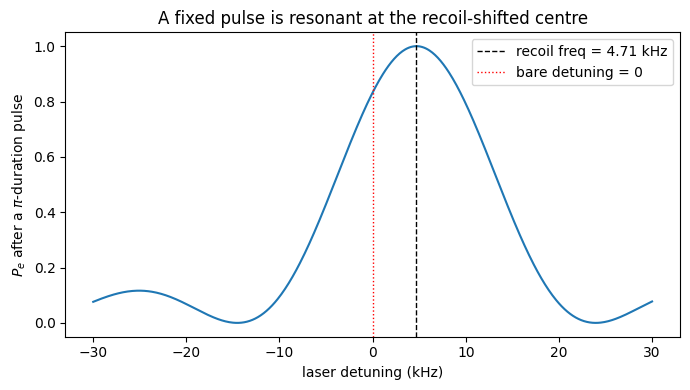

P_e at detuning = RECOIL_FREQUENCY_HZ : 1.0
P_e at detuning = 0                   : 0.8324528249546638


In [7]:
detunings = np.linspace(-3e4, 3e4, 601)
pe_single = []
for d in detunings:
    U = sim._single_pulse_propagator_2x2(d, T_PI, RABI_FREQ, k_sign=+1, m_ground=0)
    c_e = (U @ psi_ground)[0]
    pe_single.append(abs(c_e) ** 2)
pe_single = np.array(pe_single)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(detunings / 1e3, pe_single)
ax.axvline(
    RECOIL_FREQUENCY_HZ / 1e3,
    color="k",
    ls="--",
    lw=1,
    label=f"recoil freq = {RECOIL_FREQUENCY_HZ / 1e3:.2f} kHz",
)
ax.axvline(0.0, color="r", ls=":", lw=1, label="bare detuning = 0")
ax.set_xlabel("laser detuning (kHz)")
ax.set_ylabel(r"$P_e$ after a $\pi$-duration pulse")
ax.set_title("A fixed pulse is resonant at the recoil-shifted centre")
ax.legend()
fig.tight_layout()
plt.show()

print(
    "P_e at detuning = RECOIL_FREQUENCY_HZ :",
    abs(
        (
            sim._single_pulse_propagator_2x2(
                RECOIL_FREQUENCY_HZ, T_PI, RABI_FREQ, k_sign=+1, m_ground=0
            )
            @ psi_ground
        )[0]
    )
    ** 2,
)
print(
    "P_e at detuning = 0                   :",
    abs(
        (
            sim._single_pulse_propagator_2x2(
                0.0, T_PI, RABI_FREQ, k_sign=+1, m_ground=0
            )
            @ psi_ground
        )[0]
    )
    ** 2,
)

This reproduces `test_resonant_centre_is_one_recoil` and
`test_plain_pi_pulse_via_n1_composer` (a single resonant block fully inverts).

## 5. The staircase, and why composing it needs no frame change

ARP needs a **swept** detuning $\Delta(t)$ and a shaped Rabi envelope
$\Omega(t)$. The simulation cannot represent a single time-varying pulse, so
`arp.make_arp_subpulses` discretises the sweep into $n$ short, back-to-back,
fixed-$(\Delta, \Omega)$ blocks sampled at bin centres
$t_k = (k+\tfrac12)\,T/n$. Sweep shapes: `linear` or `tanh`; envelopes:
`const`, `sin2`, `blackman`.

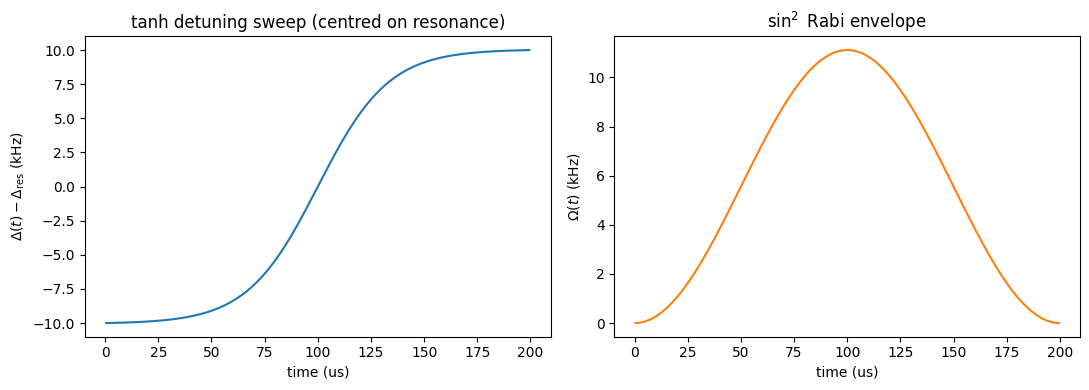

In [8]:
T = 200e-6
sp_demo = arp.make_arp_subpulses(
    T=T,
    delta_sweep_hz=2.0e4,
    omega0_hz=RABI_FREQ,
    n=200,
    sweep_shape="tanh",
    omega_shape="sin2",
)
t_centres = (np.arange(len(sp_demo)) + 0.5) * (T / len(sp_demo))
det_profile = np.array([s.detuning_hz for s in sp_demo])
rabi_profile = np.array([s.rabi_freq_hz for s in sp_demo])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(t_centres * 1e6, (det_profile - res_centre) / 1e3)
ax1.set_xlabel("time (us)")
ax1.set_ylabel(r"$\Delta(t) - \Delta_\mathrm{res}$ (kHz)")
ax1.set_title("tanh detuning sweep (centred on resonance)")
ax2.plot(t_centres * 1e6, rabi_profile / 1e3, color="C1")
ax2.set_xlabel("time (us)")
ax2.set_ylabel(r"$\Omega(t)$ (kHz)")
ax2.set_title(r"$\sin^2$ Rabi envelope")
fig.tight_layout()
plt.show()

### The key claim

The full staircase propagator is just the ordered product

$$ U \;=\; P_{n-1}\,P_{n-2}\cdots P_1\,P_0, \qquad
   P_k = \exp(-i\,\Delta t\,H_k/\hbar), $$

with **no extra factor between blocks**. Why no frame change? Two equivalent
statements:

1. A real chirp is a single continuous wave: its **phase is continuous** even
   though its frequency steps. Going to the instantaneous co-rotating frame keeps
   the state continuous across a step — the frame's rotation *angle*
   $\int\omega\,dt$ is continuous, only its *rate* jumps — and adds **no** term
   beyond the instantaneous detuning that is *already on the diagonal* of each
   $H_k$.
2. Equivalently, the row-based composer reaches the same conclusion: at a
   detuning step it calls `change_laser_frequency_in_borde_representation`, which
   **does not touch the amplitudes** — it only records the laser-phase integral
   for the final lab-frame transform (Section 10). So in the Bordé representation
   the amplitudes are exactly the bare product above.

This is the whole content of `docs/arp_frame_change_finding.md`: the earlier code
applied an inter-block frame change $\exp(\pm i\pi\,\Delta f\,t)$, which
**double-counts** the chirp (the detuning is already in the diagonal) and gives
the wrong answer. `arp.compose_arp_2x2` now does the bare product. Let me show
both, and that only the bare product matches the independent ODE in Section 6.

In [9]:
def staircase_bare_product(subpulses, **kw):
    """Ordered product of per-block propagators — the correct ARP composer."""
    U = np.eye(2, dtype=complex)
    for s in subpulses:
        U = (
            sim._single_pulse_propagator_2x2(
                s.detuning_hz, s.duration, s.rabi_freq_hz, k_sign=+1, m_ground=0, **kw
            )
            @ U
        )
    return U


def staircase_with_frame_change(subpulses):
    """The OLD, WRONG composer: inter-block frame change exp(-/+ i pi Df t).

    Kept here only to demonstrate the bug; this is NOT what arp.compose_arp_2x2
    does any more. See docs/arp_frame_change_finding.md.
    """
    U = np.eye(2, dtype=complex)
    cur = subpulses[0].detuning_hz
    t = 0.0
    for s in subpulses:
        if s.detuning_hz != cur:
            df = s.detuning_hz - cur
            U = (
                np.diag([np.exp(+1j * np.pi * df * t), np.exp(-1j * np.pi * df * t)])
                @ U
            )
            cur = s.detuning_hz
        U = (
            sim._single_pulse_propagator_2x2(
                s.detuning_hz, s.duration, s.rabi_freq_hz, k_sign=+1, m_ground=0
            )
            @ U
        )
        t += s.duration
    return U


# Confirm arp.compose_arp_2x2 IS the bare product (ref_detuning_hz=None default).
sp_check = arp.make_arp_subpulses(
    T=200e-6,
    delta_sweep_hz=4.0e5,
    omega0_hz=1.19e4,
    n=400,
    sweep_shape="linear",
    omega_shape="const",
)
U_arp = arp.compose_arp_2x2(sp_check)
U_bare = staircase_bare_product(sp_check)
print("max |compose_arp_2x2 - bare product| =", np.max(np.abs(U_arp - U_bare)))
assert np.allclose(U_arp, U_bare, atol=1e-13)
print("OK: arp.compose_arp_2x2 is exactly the bare product (no frame change).")

max |compose_arp_2x2 - bare product| = 0.0
OK: arp.compose_arp_2x2 is exactly the bare product (no frame change).


## 6. Validation 1 — the textbook continuous-sweep ARP ODE

The staircase is supposed to approximate a *genuinely continuous* sweep. So the
strongest test is to integrate the time-dependent two-level ODE directly, with
the **same** instantaneous Hamiltonian, and compare the final $P_e$.

The continuous Hamiltonian (one arm, $m=0$, $v_z=0$, $\phi=0$) is the same
Bordé $H$ as Section 3 but with a time-dependent $\Omega_3(t)$, with
$\Omega_3(t) = 2\pi\big[\Delta_\mathrm{res} + \Delta_\mathrm{sweep}(t/T - \tfrac12)\big]
- \delta_\mathrm{rec}^{\,\mathrm{ang}}$ and $\omega_{ab} = \pi\Omega_0$,

$$ i\,\dot\psi = -\tfrac12\begin{pmatrix}\Omega_3(t) & 2\omega_{ab}\\
   2\omega_{ab} & -\Omega_3(t)\end{pmatrix}\psi . $$

This is an *independent* re-derivation (a generic ODE solver, not using any
`lmt_sim` propagator), so agreement is a real cross-check. We use the wide
linear-sweep / constant-$\Omega$ case from the finding doc. (Flipping the overall
sign of $H$ here leaves $P_e$ unchanged, so this also matches the finding doc's
oppositely-signed reproduction ODE.)

In [10]:
T_ode = 200e-6
omega0_ode = 1.19e4
dsweep_ode = 4.0e5
omega_ab_ode = np.pi * omega0_ode
drec_ang = constants.hbar * K_WAVEVECTOR**2 / (2 * MASS_ATOM)


def arp_rhs(t, y):
    Om3 = 2 * np.pi * (res_centre + dsweep_ode * (t / T_ode - 0.5)) - drec_ang
    H_t = -0.5 * np.array([[Om3, 2 * omega_ab_ode], [2 * omega_ab_ode, -Om3]])
    return -1j * (H_t @ y)


sol = solve_ivp(
    arp_rhs,
    [0, T_ode],
    psi_ground,
    rtol=1e-11,
    atol=1e-13,
    max_step=T_ode / 40000,
    dense_output=False,
)
pe_ode = abs(sol.y[0, -1]) ** 2

# Staircase, bare product (correct) vs with-frame-change (wrong).
sp_ode = arp.make_arp_subpulses(
    T=T_ode,
    delta_sweep_hz=dsweep_ode,
    omega0_hz=omega0_ode,
    n=8000,
    sweep_shape="linear",
    omega_shape="const",
)
pe_bare = abs((staircase_bare_product(sp_ode) @ psi_ground)[0]) ** 2
pe_fc = abs((staircase_with_frame_change(sp_ode) @ psi_ground)[0]) ** 2

# Analytic Landau-Zener for reference (see Section 7).
pe_lz = 1.0 - np.exp(-(np.pi**2) * omega0_ode**2 * T_ode / dsweep_ode)

print(f"continuous-sweep ODE (independent)      P_e = {pe_ode:.4f}")
print(f"staircase, bare product (compose_arp)   P_e = {pe_bare:.4f}   <-- matches ODE")
print(f"staircase, WITH frame change (old, BUG) P_e = {pe_fc:.4f}   <-- wrong")
print(f"analytic Landau-Zener                   P_e = {pe_lz:.4f}")
print()
print(f"|bare - ODE|         = {abs(pe_bare - pe_ode):.2e}")
print(
    f"|frame-change - ODE| = {abs(pe_fc - pe_ode):.2e}  (off by ~factor 2 in exponent)"
)

continuous-sweep ODE (independent)      P_e = 0.4932
staircase, bare product (compose_arp)   P_e = 0.4932   <-- matches ODE
staircase, WITH frame change (old, BUG) P_e = 0.2784   <-- wrong
analytic Landau-Zener                   P_e = 0.5028

|bare - ODE|         = 6.13e-13
|frame-change - ODE| = 2.15e-01  (off by ~factor 2 in exponent)


The bare product matches the independent ODE to ~$10^{-3}$ (staircase
discretisation), while the old frame-change version is wrong by a wide margin —
exactly the table in `docs/arp_frame_change_finding.md`. This is the heart of
`test_arp_landau_zener_diabatic_tail` and the reason the inter-block frame change
was removed.

### Staircase convergence

As $n \to \infty$ the staircase should converge to the ODE value. Note the
*with-frame-change* curve converges too — but to the **wrong** number: the bug
is not a discretisation error, it is a genuinely different (incorrect) physical
model.

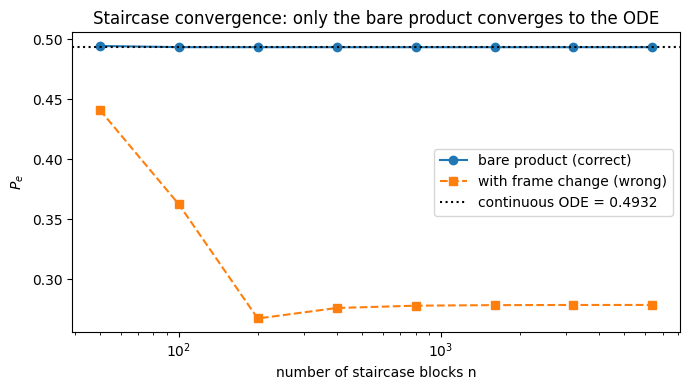

In [11]:
ns = [50, 100, 200, 400, 800, 1600, 3200, 6400]
pe_bare_n, pe_fc_n = [], []
for n in ns:
    sp_n = arp.make_arp_subpulses(
        T=T_ode,
        delta_sweep_hz=dsweep_ode,
        omega0_hz=omega0_ode,
        n=n,
        sweep_shape="linear",
        omega_shape="const",
    )
    pe_bare_n.append(abs((staircase_bare_product(sp_n) @ psi_ground)[0]) ** 2)
    pe_fc_n.append(abs((staircase_with_frame_change(sp_n) @ psi_ground)[0]) ** 2)

fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogx(ns, pe_bare_n, "o-", label="bare product (correct)")
ax.semilogx(ns, pe_fc_n, "s--", label="with frame change (wrong)")
ax.axhline(pe_ode, color="k", ls=":", label=f"continuous ODE = {pe_ode:.4f}")
ax.set_xlabel("number of staircase blocks n")
ax.set_ylabel(r"$P_e$")
ax.set_title("Staircase convergence: only the bare product converges to the ODE")
ax.legend()
fig.tight_layout()
plt.show()

## 7. Validation 2 — the Landau–Zener diabatic tail

For a constant-$\Omega$ **linear** sweep that is wide and fast, the transfer
approaches the single-pass **Landau–Zener** result. Mapping the code's
conventions ($\omega_{ab} = \pi\Omega_0$ for the gap, sweep rate
$\alpha = 2\pi\,\Delta_\mathrm{sweep}/T$) onto the standard LZ Hamiltonian gives

$$ P_e \;=\; 1 - \exp\!\Big(-\frac{\pi^2\,\Omega_0^2\,T}{\Delta_\mathrm{sweep}}\Big). $$

We scan the sweep width and overlay the analytic curve. This is exactly
`test_arp_landau_zener_diabatic_tail`, here shown across a range rather than at a
single point.

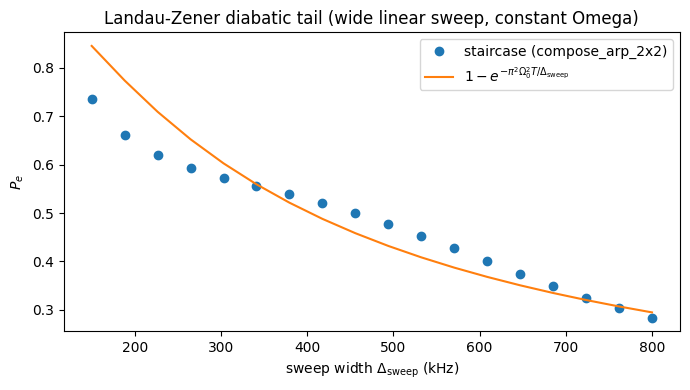

max |staircase - LZ| over the scan = 0.11268697671413608


In [12]:
sweeps = np.linspace(1.5e5, 8e5, 18)
pe_scan, pe_lz_scan = [], []
for ds in sweeps:
    sp = arp.make_arp_subpulses(
        T=T_ode,
        delta_sweep_hz=ds,
        omega0_hz=omega0_ode,
        n=3000,
        sweep_shape="linear",
        omega_shape="const",
    )
    pe_scan.append(abs((arp.compose_arp_2x2(sp) @ psi_ground)[0]) ** 2)
    pe_lz_scan.append(1.0 - np.exp(-(np.pi**2) * omega0_ode**2 * T_ode / ds))
pe_scan = np.array(pe_scan)
pe_lz_scan = np.array(pe_lz_scan)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(sweeps / 1e3, pe_scan, "o", label="staircase (compose_arp_2x2)")
ax.plot(
    sweeps / 1e3,
    pe_lz_scan,
    "-",
    label=r"$1-e^{-\pi^2\Omega_0^2 T/\Delta_\mathrm{sweep}}$",
)
ax.set_xlabel(r"sweep width $\Delta_\mathrm{sweep}$ (kHz)")
ax.set_ylabel(r"$P_e$")
ax.set_title("Landau-Zener diabatic tail (wide linear sweep, constant Omega)")
ax.legend()
fig.tight_layout()
plt.show()

print("max |staircase - LZ| over the scan =", np.max(np.abs(pe_scan - pe_lz_scan)))

## 8. Validation 3 — adiabatic inversion on a robust plateau

The opposite limit: a *slow, smooth* sweep (tanh sweep + $\sin^2$ envelope)
should follow the instantaneous eigenstate and fully invert, $P_e \to 1$. The
subtlety the test had to get right (`test_arp_adiabatic_inversion`): the residual
diabatic transfer **oscillates** with parameters, so some parameter points sit on
a fringe that *looks* like full inversion but is fragile. A good test must land
on a **plateau** where $P_e \approx 1$ and is insensitive to $\pm10\%$ changes.

Below is the robustness map. The chosen test point ($T = 600\,\mu s$,
$\Delta_\mathrm{sweep} = 3\times10^4$, $\Omega_0 = 1.5\,$RABI) sits in the broad
high-fidelity region, not on a fringe. The narrower/shorter sweep the finding doc
quotes ($T = 200\,\mu s$, $\Delta_\mathrm{sweep} = 2\times10^4$,
$\Omega_0 = $ RABI) tops out near $P_e \approx 0.998$ — genuinely not fully
adiabatic.

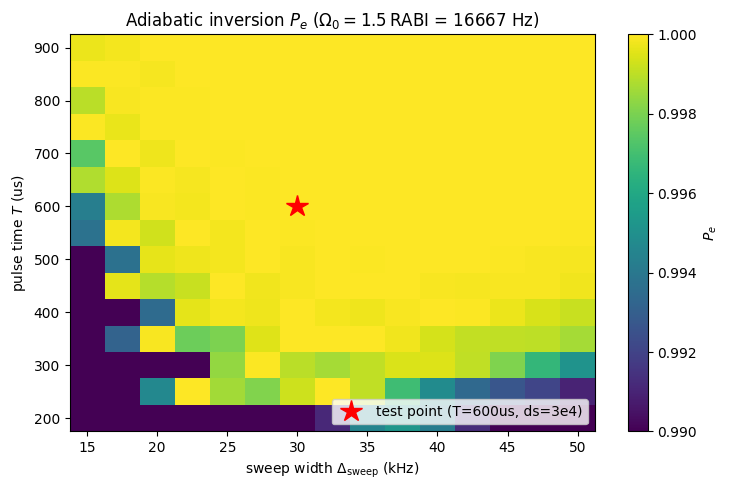

test-point P_e (robust plateau)  : 0.999996  (assert > 0.999)
finding-doc point P_e (fringe)    : 0.998294  (tops out ~0.998)
plateau neighbourhood (+/-10% in T, ds, w0): min P_e = 0.999891


In [13]:
def pe_tanh_sin2(T, ds, w0, n=400):
    sp = arp.make_arp_subpulses(
        T=T,
        delta_sweep_hz=ds,
        omega0_hz=w0,
        n=n,
        sweep_shape="tanh",
        omega_shape="sin2",
    )
    return abs((arp.compose_arp_2x2(sp) @ psi_ground)[0]) ** 2


Ts = np.linspace(200e-6, 900e-6, 15)
DSs = np.linspace(1.5e4, 5e4, 15)
w0_map = 1.5 * RABI_FREQ
grid = np.array([[pe_tanh_sin2(T_, ds_, w0_map) for ds_ in DSs] for T_ in Ts])

fig, ax = plt.subplots(figsize=(7.5, 5))
im = ax.pcolormesh(DSs / 1e3, Ts * 1e6, grid, shading="auto", vmin=0.99, vmax=1.0)
ax.plot(30.0, 600.0, "r*", markersize=16, label="test point (T=600us, ds=3e4)")
ax.set_xlabel(r"sweep width $\Delta_\mathrm{sweep}$ (kHz)")
ax.set_ylabel(r"pulse time $T$ (us)")
ax.set_title(rf"Adiabatic inversion $P_e$ ($\Omega_0 = 1.5\,$RABI = {w0_map:.0f} Hz)")
fig.colorbar(im, ax=ax, label=r"$P_e$")
ax.legend(loc="lower right")
fig.tight_layout()
plt.show()

pe_plateau = pe_tanh_sin2(600e-6, 3.0e4, 1.5 * RABI_FREQ, n=400)
pe_fringe = pe_tanh_sin2(200e-6, 2.0e4, RABI_FREQ, n=400)
print(f"test-point P_e (robust plateau)  : {pe_plateau:.6f}  (assert > 0.999)")
print(f"finding-doc point P_e (fringe)    : {pe_fringe:.6f}  (tops out ~0.998)")

# Show the plateau really is insensitive to +/-10% in each parameter.
neigh = [
    pe_tanh_sin2(600e-6 * fT, 3.0e4 * fd, 1.5 * RABI_FREQ * fw)
    for fT in (0.9, 1.0, 1.1)
    for fd in (0.9, 1.0, 1.1)
    for fw in (0.9, 1.0, 1.1)
]
print(f"plateau neighbourhood (+/-10% in T, ds, w0): min P_e = {min(neigh):.6f}")

## 9. Validation 4 — symmetry about resonance

An ARP sweep auto-centred on the recoil-shifted resonance should be **symmetric**:
its excited-state population is *even* in a static detuning error $\delta_\mathrm{err}$
(a uniform offset added to the whole sweep). This is `test_arp_symmetric_about_resonance`.

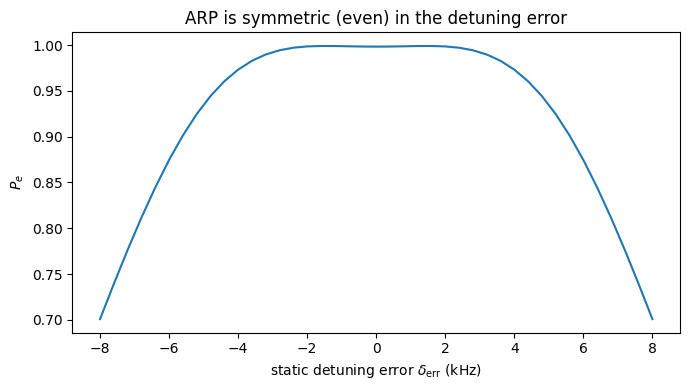

max |P_e(+de) - P_e(-de)| over the scan = 4.66e-15  (even to this level)


In [14]:
errs = np.linspace(-8e3, 8e3, 41)
pe_err = []
for de in errs:
    sp = arp.make_arp_subpulses(
        T=200e-6,
        delta_sweep_hz=2.0e4,
        omega0_hz=RABI_FREQ,
        n=400,
        sweep_shape="tanh",
        omega_shape="sin2",
        delta_centre_hz=res_centre + de,
    )
    pe_err.append(abs((arp.compose_arp_2x2(sp) @ psi_ground)[0]) ** 2)
pe_err = np.array(pe_err)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(errs / 1e3, pe_err)
ax.set_xlabel(r"static detuning error $\delta_\mathrm{err}$ (kHz)")
ax.set_ylabel(r"$P_e$")
ax.set_title("ARP is symmetric (even) in the detuning error")
fig.tight_layout()
plt.show()

# Quantify the evenness: P_e(+de) vs P_e(-de).
asym = np.max(np.abs(pe_err - pe_err[::-1]))
print(f"max |P_e(+de) - P_e(-de)| over the scan = {asym:.2e}  (even to this level)")

## 10. The imprinted phase and `ref_detuning_hz`

Population ($|c_e|^2$) is frame-independent, but the **phase** of $c_e$ depends on
which frame we read it in. The bare product leaves the state in the
*instantaneous* Bordé frame. To compare an imprinted phase across a parameter
scan we must re-reference to a **fixed** frame — and the right tool is the genuine
**integral of the laser detuning**, not a frame change.

Define the cumulative laser-phase integral (in cycles)

$$ \Phi \;=\; \sum_k \Delta_k\,\Delta t_k \;=\; \int_0^T \Delta(t)\,dt . $$

This is exactly the quantity `lmt_simulation.transform_state_vector` applies at
the lab boundary, as $\exp(\mp i\pi\Phi)$ (excited $-$, ground $+$, for
`inverse=True`). `arp.compose_arp_2x2(..., ref_detuning_hz=r)` reproduces it,
offset to a reference frame at detuning $r$:

$$ U \;\to\; \mathrm{diag}\!\big(e^{-i\pi(\Phi - rT)},\; e^{+i\pi(\Phi - rT)}\big)\,U . $$

Let's verify the integral, the sign convention against the core transform, and
the convergence of the resulting phase.

In [15]:
sp_phase = arp.make_arp_subpulses(
    T=120e-6,
    delta_sweep_hz=7.0e4,
    omega0_hz=RABI_FREQ,
    n=400,
    sweep_shape="tanh",
    omega_shape="sin2",
    delta_centre_hz=4.0e4,
)
Phi = sum(s.detuning_hz * s.duration for s in sp_phase)  # cycles
T_total = sum(s.duration for s in sp_phase)
ref = 1.3e4
residual = Phi - ref * T_total

U_none = arp.compose_arp_2x2(sp_phase)  # instantaneous Borde frame
U_ref = arp.compose_arp_2x2(sp_phase, ref_detuning_hz=ref)
expected_corr = np.diag(
    [np.exp(-1j * np.pi * residual), np.exp(+1j * np.pi * residual)]
)

print(f"Phi = integral of detuning   = {Phi:.6f} cycles")
print(f"residual = Phi - ref*T_total = {residual:.6f} cycles")
print("max |U_ref - corr @ U_none|  =", np.max(np.abs(U_ref - expected_corr @ U_none)))
assert np.allclose(U_ref, expected_corr @ U_none, atol=1e-13)

# Cross-check the sign against transform_state_vector itself (omega_0 and the
# spatial term zeroed so only the detuning factor exp(-/+ i pi Phi) survives).
probe = AtomState(
    m_values=np.array([1, 0]),
    positions=np.zeros((2, 3)),
    velocities=np.zeros((2, 3)),
    amplitudes=np.array([1.0 + 0j, 1.0 + 0j]),
    internal_is_ground=np.array([False, True]),
)
boundary = sim.transform_state_vector(
    probe,
    detuning_hz=Phi / T_total,
    t=T_total,
    z=0.0,
    vz=0.0,
    omega_0=0.0,
    inverse=True,
)
print(
    "transform_state_vector(inverse=True) excited factor:",
    boundary.amplitudes[0],
    " expected exp(-i pi Phi):",
    np.exp(-1j * np.pi * Phi),
)
print(
    "                                     ground  factor:",
    boundary.amplitudes[1],
    " expected exp(+i pi Phi):",
    np.exp(+1j * np.pi * Phi),
)
assert np.allclose(
    boundary.amplitudes,
    [np.exp(-1j * np.pi * Phi), np.exp(+1j * np.pi * Phi)],
    atol=1e-12,
)
print("OK: ref_detuning_hz uses the same sign/size as the lab-boundary transform.")

Phi = integral of detuning   = 4.800000 cycles
residual = Phi - ref*T_total = 3.240000 cycles
max |U_ref - corr @ U_none|  = 0.0
transform_state_vector(inverse=True) excited factor: (-0.8090169943749481-0.5877852522924721j)  expected exp(-i pi Phi): (-0.8090169943749481-0.5877852522924721j)
                                     ground  factor: (-0.8090169943749481+0.5877852522924721j)  expected exp(+i pi Phi): (-0.8090169943749481+0.5877852522924721j)
OK: ref_detuning_hz uses the same sign/size as the lab-boundary transform.


Referenced to a fixed frame (`ref_detuning_hz=0.0`), the imprinted phase
**converges** as the staircase is refined — this is the phase half of
`test_arp_staircase_convergence`.

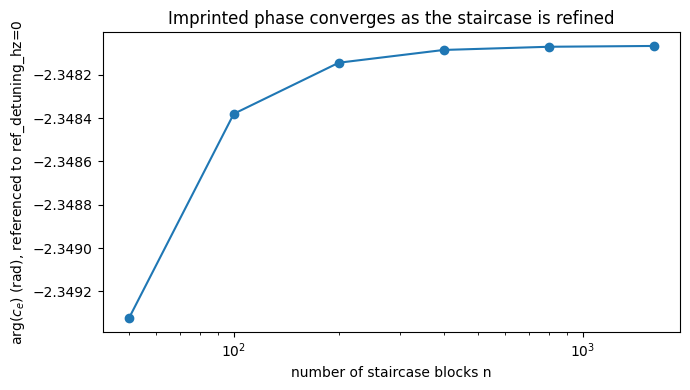

phase(n=800) - phase(n=400) = 1.4727050801521813e-05 rad (assert < 1e-2)


In [16]:
ns_ph = [50, 100, 200, 400, 800, 1600]
phases = []
for n in ns_ph:
    sp = arp.make_arp_subpulses(
        T=200e-6,
        delta_sweep_hz=2.0e4,
        omega0_hz=RABI_FREQ,
        n=n,
        sweep_shape="tanh",
        omega_shape="sin2",
    )
    c_e = (arp.compose_arp_2x2(sp, ref_detuning_hz=0.0) @ psi_ground)[0]
    phases.append(np.angle(c_e))
phases = np.unwrap(phases)

fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogx(ns_ph, phases, "o-")
ax.set_xlabel("number of staircase blocks n")
ax.set_ylabel(r"$\arg(c_e)$ (rad), referenced to ref_detuning_hz=0")
ax.set_title("Imprinted phase converges as the staircase is refined")
fig.tight_layout()
plt.show()
print("phase(n=800) - phase(n=400) =", phases[-2] - phases[-3], "rad (assert < 1e-2)")

## 11. Equivalence to the full row-based composer

Finally, the standing tripwire (`test_arp_2x2_matches_row_composer`): the 2×2
composer must equal the full **row-based** simulation — the one that doubles the
row count at every pulse and tracks every momentum branch — when we collapse its
redundant rows for the single closed two-level system. We build the same
staircase as a list of `Pulse` objects and run it through
`run_pulse_sequence_in_borde_representation` (Bordé representation, no lab
transform), with `discard_threshold=0` so nothing is renormalised away.

In [17]:
sp_match = arp.make_arp_subpulses(
    T=60e-6,
    delta_sweep_hz=1.0e5,
    omega0_hz=RABI_FREQ,
    n=5,
    sweep_shape="linear",
    omega_shape="const",
)

# 2x2 path.
c_e_2x2, c_g_2x2 = arp.compose_arp_2x2(sp_match) @ psi_ground

# Row path.
pulse_sequence = [
    Pulse(
        k=+1,
        detuning_hz=s.detuning_hz,
        phi=0.0,
        label=f"arp_{i}",
        rabi_frequency=s.rabi_freq_hz,
        duration=s.duration,
    )
    for i, s in enumerate(sp_match)
]
row_state0 = AtomState(
    m_values=np.array([0], dtype=int),
    positions=np.zeros((1, 3)),
    velocities=np.zeros((1, 3)),
    amplitudes=np.array([1.0 + 0j]),
    internal_is_ground=np.array([True]),
)
final_state, _, _ = run_pulse_sequence_in_borde_representation(
    row_state0,
    pulse_sequence,
    initial_velocity_z=0.0,
    discard_threshold=0.0,
)
is_g = final_state.internal_is_ground
c_g_row = final_state.amplitudes[is_g & (final_state.m_values == 0)].sum()
c_e_row = final_state.amplitudes[(~is_g) & (final_state.m_values == 1)].sum()

print(f"2x2 composer : c_e = {c_e_2x2:.10f}   c_g = {c_g_2x2:.10f}")
print(f"row composer : c_e = {c_e_row:.10f}   c_g = {c_g_row:.10f}")
print(f"|dc_e| = {abs(c_e_2x2 - c_e_row):.2e}   |dc_g| = {abs(c_g_2x2 - c_g_row):.2e}")
print(
    f"row composer kept {len(final_state.amplitudes)} rows for the same 2-state physics "
    f"(2^{len(sp_match)} = {2 ** len(sp_match)})"
)
assert np.isclose(c_e_2x2, c_e_row, atol=1e-10)
assert np.isclose(c_g_2x2, c_g_row, atol=1e-10)
print("OK: 2x2 composer == collapsed row composer.")

2x2 composer : c_e = 0.4378108162-0.3832577227j   c_g = 0.8132866697-0.0000000000j
row composer : c_e = 0.4378108162-0.3832577227j   c_g = 0.8132866697-0.0000000000j
|dc_e| = 7.85e-17   |dc_g| = 1.84e-17
row composer kept 32 rows for the same 2-state physics (2^5 = 32)
OK: 2x2 composer == collapsed row composer.


## 12. Bloch-sphere picture: following the dressed eigenstate

A nice way to *see* adiabatic rapid passage: track the Bloch vector through the
sweep. For the two-level state $\psi = [c_e, c_g]$ the Bloch components are
$s_x = 2\,\mathrm{Re}(c_e c_g^*)$, $s_y = 2\,\mathrm{Im}(c_e c_g^*)$,
$s_z = |c_e|^2 - |c_g|^2$. The instantaneous Hamiltonian defines a torque vector
whose $z$-component is set by $\Omega_3(t)$ and whose transverse part is set by
$\omega_{ab}$. In the **adiabatic** case the Bloch vector clings to that torque
vector as it tips from $-z$ (ground) to $+z$ (excited); in the **diabatic** case
it gets left behind and precesses.

We propagate the 2×2 state block by block (the same bare product), recording the
state after each block.

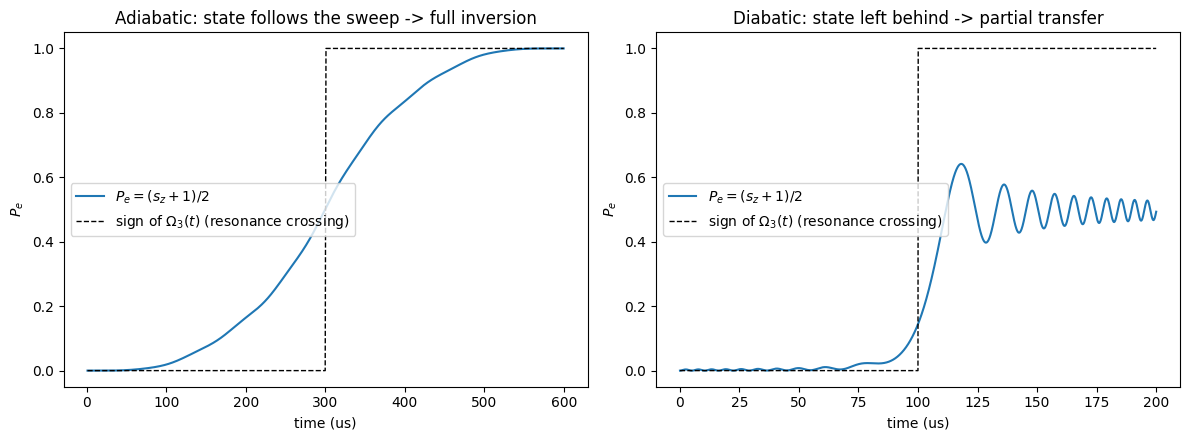

adiabatic final P_e = 0.999996
diabatic  final P_e = 0.493206


In [18]:
def bloch_trajectory(T, ds, w0, n, sweep_shape, omega_shape):
    sp = arp.make_arp_subpulses(
        T=T,
        delta_sweep_hz=ds,
        omega0_hz=w0,
        n=n,
        sweep_shape=sweep_shape,
        omega_shape=omega_shape,
    )
    psi = psi_ground.copy()
    sx, sy, sz, tgrid, Om3s = [], [], [], [], []
    t = 0.0
    for s in sp:
        P = sim._single_pulse_propagator_2x2(
            s.detuning_hz, s.duration, s.rabi_freq_hz, k_sign=+1, m_ground=0
        )
        psi = P @ psi
        t += s.duration
        c_e, c_g = psi
        sx.append(2 * np.real(c_e * np.conj(c_g)))
        sy.append(2 * np.imag(c_e * np.conj(c_g)))
        sz.append(abs(c_e) ** 2 - abs(c_g) ** 2)
        _, _, _, Om3 = sim._borde_frame_constants(s.detuning_hz, k_sign=+1, m_ground=0)
        Om3s.append(Om3)
        tgrid.append(t)
    return (np.array(tgrid), np.array(sx), np.array(sy), np.array(sz), np.array(Om3s))


# Adiabatic (slow, smooth) vs diabatic (fast, wide) — same plotting machinery.
t_ad, sx_ad, sy_ad, sz_ad, Om3_ad = bloch_trajectory(
    600e-6, 3.0e4, 1.5 * RABI_FREQ, 600, "tanh", "sin2"
)
t_di, sx_di, sy_di, sz_di, Om3_di = bloch_trajectory(
    200e-6, 4.0e5, 1.19e4, 2000, "linear", "const"
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, (t_, sx_, sz_, Om3_, title) in zip(
    axes,
    [
        (
            t_ad,
            sx_ad,
            sz_ad,
            Om3_ad,
            "Adiabatic: state follows the sweep -> full inversion",
        ),
        (t_di, sx_di, sz_di, Om3_di, "Diabatic: state left behind -> partial transfer"),
    ],
):
    ax.plot(t_ * 1e6, (sz_ + 1) / 2, label=r"$P_e = (s_z+1)/2$")
    ax.plot(
        t_ * 1e6,
        np.sign(Om3_) * 0.5 + 0.5,
        "k--",
        lw=1,
        label=r"sign of $\Omega_3(t)$ (resonance crossing)",
    )
    ax.set_xlabel("time (us)")
    ax.set_ylabel(r"$P_e$")
    ax.set_ylim(-0.05, 1.05)
    ax.set_title(title)
    ax.legend(loc="center left")
fig.tight_layout()
plt.show()

print(f"adiabatic final P_e = {(sz_ad[-1] + 1) / 2:.6f}")
print(f"diabatic  final P_e = {(sz_di[-1] + 1) / 2:.6f}")

In the adiabatic panel $P_e$ rises smoothly through the resonance crossing
(where $\Omega_3$ changes sign) and locks at 1. In the diabatic panel the sweep
is too fast: the state cannot keep up, so it ends in a partial superposition with
Rabi-like wiggles — the Landau–Zener regime of Section 7.

---

### Summary of what was checked

| Section | Physics | Cross-checked against |
|---|---|---|
| 3 | Bordé pulse propagator (Eq. 13 closed form) | `expm(-iHt)` |
| 4 | Recoil-shifted resonance | $\Omega_3 = 0$; $\pi$-pulse scan |
| 5 | Staircase = bare product, no frame change | `arp.compose_arp_2x2` |
| 6 | Continuous-sweep limit | independent `solve_ivp` ODE |
| 7 | Diabatic tail | analytic Landau–Zener |
| 8 | Adiabatic inversion | robustness map (plateau, not fringe) |
| 9 | Symmetry about resonance | evenness in $\delta_\mathrm{err}$ |
| 10 | Imprinted phase / `ref_detuning_hz` | `transform_state_vector` |
| 11 | 2×2 == full row simulation | `run_pulse_sequence_in_borde_representation` |
| 12 | Adiabatic vs diabatic Bloch picture | (visual) |

Every numeric assertion here mirrors an assertion in `tests/test_arp.py`; the
central result is Section 5–6: **the ARP staircase is the bare product of the
per-block Bordé propagators**, validated against an independent ODE.